Пункт (a):
  Общее расстояние за 1000 шагов: 232388
  Средний поток (авто/шаг): 232.39


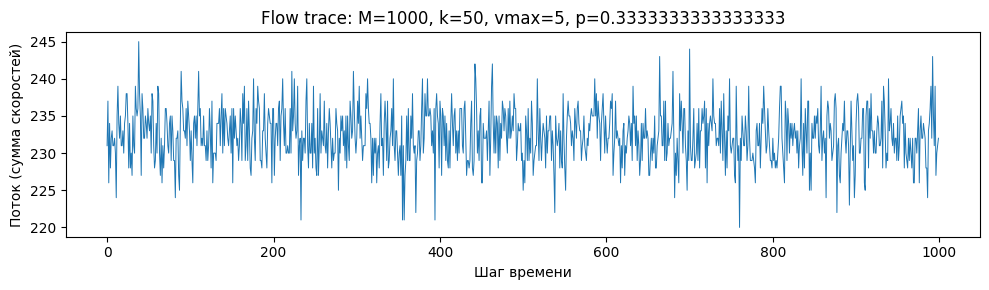

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def nagel_schreckenberg(M, k, vmax, p, steps, burn_in=0, init='uniform', seed=None):
    rng = np.random.default_rng(seed)
    if init == 'uniform':
        # приблизительно равномерно
        positions = np.sort(rng.choice(M, size=k, replace=False))
    elif init == 'compact':
        # от 0 до k-1
        positions = np.arange(k)
    elif init == 'random':
        positions = np.sort(rng.choice(M, size=k, replace=False))
    
    vel = np.zeros(k, dtype=int)
    
    total_distance = 0
    flow_trace = []
    
    for t in range(burn_in + steps):
        # расстояния до следующего авто
        pos_ext = np.concatenate([positions, [positions[0] + M]])
        gaps = np.diff(pos_ext) - 1
        
        # 1) ускорение
        vel = np.minimum(vel + 1, vmax)
        # 2) торможение
        vel = np.minimum(vel, gaps)
        # 3) случайность
        mask = rng.random(k) < p
        vel[mask] = np.maximum(vel[mask] - 1, 0)
        # 4) движение
        positions = (positions + vel) % M
        positions = np.sort(positions)
        
        if t >= burn_in:
            total_distance += int(np.sum(vel))
            flow_trace.append(int(np.sum(vel)))
    
    return total_distance, flow_trace, positions, vel

# ---------- Пункт (a) ----------
M, B, vmax, k, p = 1000, 1000, 5, 50, 1/3
dist_a, flow_a, _, _ = nagel_schreckenberg(M, k, vmax, p, steps=1000, burn_in=B, seed=42)

print("Пункт (a):")
print(f"  Общее расстояние за 1000 шагов: {dist_a}")
print(f"  Средний поток (авто/шаг): {dist_a/1000:.2f}")

plt.figure(figsize=(10,3))
plt.plot(flow_a, lw=0.7)
plt.xlabel("Шаг времени")
plt.ylabel("Поток (сумма скоростей)")
plt.title(f"Flow trace: M={M}, k={k}, vmax={vmax}, p={p}")
plt.tight_layout()
plt.savefig("flow_trace_k50.png", dpi=100)
plt.show()

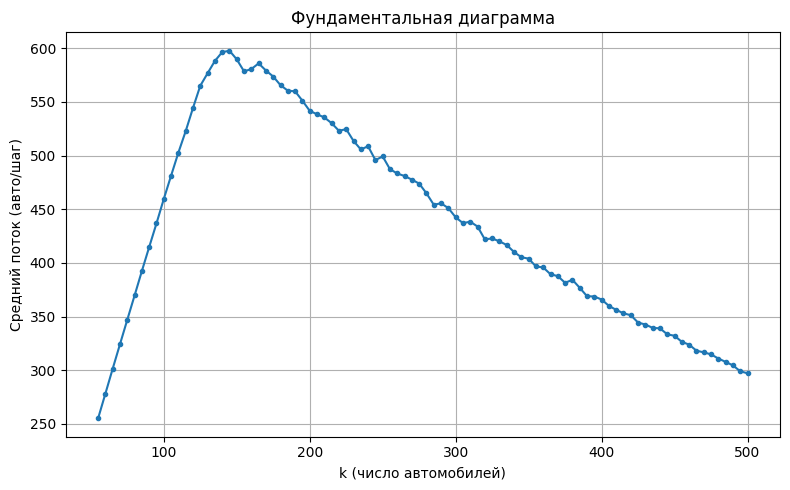

In [3]:
ks = list(range(55, 501, 5))
flows = []
for k in ks:
    d, _, _, _ = nagel_schreckenberg(M, k, vmax, p, steps=1000, burn_in=B, seed=1234)
    flows.append(d / 1000)   # средний поток за шаг

plt.figure(figsize=(8,5))
plt.plot(ks, flows, 'o-', ms=3)
plt.xlabel("k (число автомобилей)")
plt.ylabel("Средний поток (авто/шаг)")
plt.title("Фундаментальная диаграмма")
plt.grid(True)
plt.tight_layout()
plt.savefig("fundamental.png", dpi=100)
plt.show()

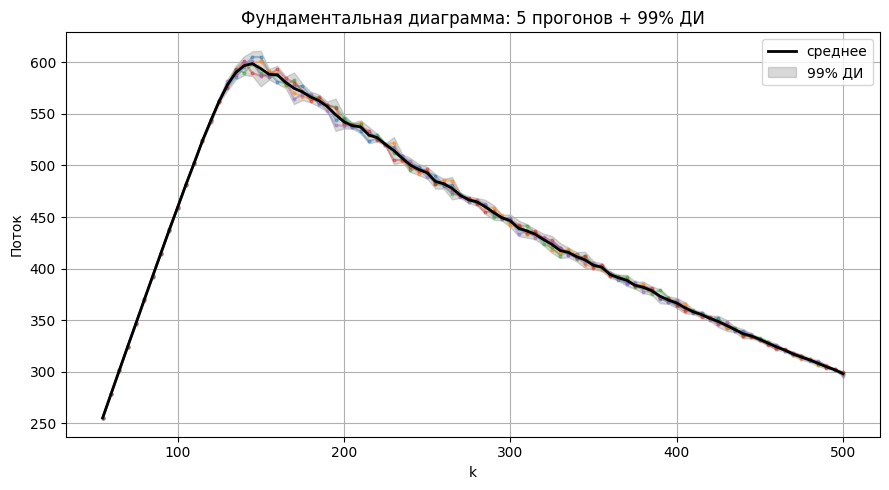

In [4]:
n_repeats = 5   # одно уже есть + 4 новых
all_flows = np.zeros((n_repeats, len(ks)))
for r in range(n_repeats):
    for i, k in enumerate(ks):
        d, _, _, _ = nagel_schreckenberg(M, k, vmax, p, steps=1000, burn_in=B,
                                          seed=1000 + 7*r + i)
        all_flows[r, i] = d / 1000

mean_flow = all_flows.mean(axis=0)
std_flow  = all_flows.std(axis=0, ddof=1)
# 99% доверительные границы для среднего (t-распределение, 4 ст.св.)
from scipy import stats
t_crit = stats.t.ppf(0.995, df=n_repeats-1)   # ≈ 4.604
ci_lo = mean_flow - t_crit * std_flow / np.sqrt(n_repeats)
ci_hi = mean_flow + t_crit * std_flow / np.sqrt(n_repeats)

plt.figure(figsize=(9,5))
for r in range(n_repeats):
    plt.plot(ks, all_flows[r], 'o-', ms=2, alpha=0.4)
plt.plot(ks, mean_flow, 'k-', lw=2, label='среднее')
plt.fill_between(ks, ci_lo, ci_hi, color='gray', alpha=0.3, label='99% ДИ')
plt.xlabel("k"); plt.ylabel("Поток")
plt.legend(); plt.grid(True)
plt.title("Фундаментальная диаграмма: 5 прогонов + 99% ДИ")
plt.tight_layout()
plt.savefig("fundamental_ci.png", dpi=100)
plt.show()

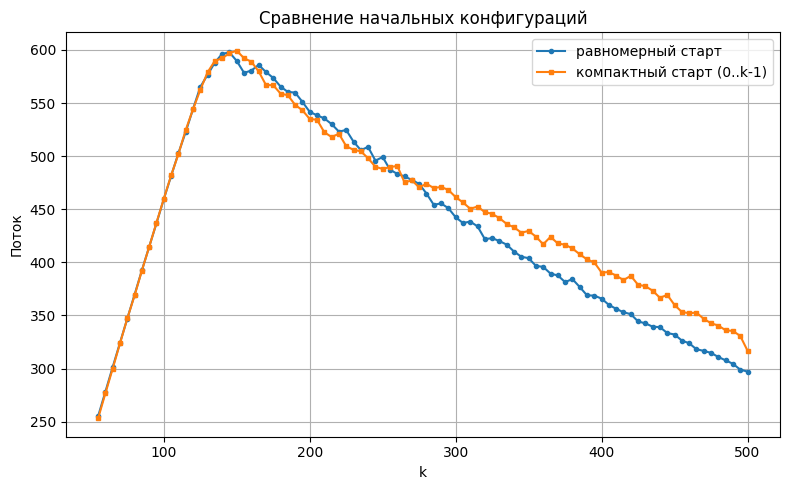

In [5]:
flows_compact = []
for k in ks:
    d, _, _, _ = nagel_schreckenberg(M, k, vmax, p, steps=1000, burn_in=B,
                                     init='compact', seed=555)
    flows_compact.append(d / 1000)

plt.figure(figsize=(8,5))
plt.plot(ks, flows, 'o-', ms=3, label='равномерный старт')
plt.plot(ks, flows_compact, 's-', ms=3, label='компактный старт (0..k-1)')
plt.xlabel("k"); plt.ylabel("Поток")
plt.legend(); plt.grid(True)
plt.title("Сравнение начальных конфигураций")
plt.tight_layout()
plt.savefig("compact_vs_uniform.png", dpi=100)
plt.show()